<h2>TF-IDF</h2>

Dataset

In [56]:
import pandas as pd 


train = pd.read_csv("./data/train.csv")
val = pd.read_csv("./data/val.csv")
test = pd.read_csv("./data/test.csv")

In [57]:
train.shape
val.shape
test.shape

(9469, 3)

In [58]:
X_train = train[["title", "text"]]
y_train = train["label"]

X_val = val[["title", "text"]]
y_val = val["label"]

X_test = test[["title", "text"]]
y_test = test["label"]

print(val["title"][0])
print(test["title"][0])

when duterte met abe
trump promised to repeal obamacare. now what?


In [ ]:
from scipy.sparse import hstack
from sklearn.feature_extraction.text import TfidfVectorizer


title_vectorizer = TfidfVectorizer(
    stop_words='english',
    ngram_range=(1, 2),  
    sublinear_tf=True,   
    norm='l2'
)


text_vectorizer = TfidfVectorizer(
    stop_words='english',
    ngram_range=(1, 2),  
    sublinear_tf=True,   
    norm='l2'
)


tfidf_title_matrix = title_vectorizer.fit_transform(X_train["title"])
tfidf_text_matrix = text_vectorizer.fit_transform(X_train["text"])
X_train_features = hstack([tfidf_title_matrix, tfidf_text_matrix]).tocsr()


# test and val
tfidf_title_val_matrix = title_vectorizer.transform(X_val["title"])
tfidf_text_val_matrix = text_vectorizer.transform(X_val["text"])
X_val_features = hstack([tfidf_title_val_matrix, tfidf_text_val_matrix]).tocsr()


tfidf_title_test_matrix = title_vectorizer.transform(X_test["title"])
tfidf_text_test_matrix = text_vectorizer.transform(X_test["text"])
X_test_features = hstack([tfidf_title_test_matrix, tfidf_text_test_matrix]).tocsr()

In [65]:
print("train ",X_train_features.shape)

print("validation ",X_val_features.shape)

print("test ",X_test_features.shape)

train  (44184, 6339503)
validation  (9468, 6339503)
test  (9469, 6339503)


<h2>Logistic Regression</h2>

In [66]:
y_train.value_counts(normalize=True)

label
0    0.551172
1    0.448828
Name: proportion, dtype: float64

In [67]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score, accuracy_score,classification_report
import time

# $0.23/hr for AWS ml.m5.xlarge
HOURLY_INSTANCE_RATE_USD = 0.23


clf = LogisticRegression(
    C=1.0,               
    max_iter=1000,       
    solver='lbfgs',    
    # class_weight='balanced', #0.551172 of 0 and 0.448828 of 1
    random_state=42
)

start_time = time.perf_counter()
clf.fit(X_train_features, y_train)
end_time = time.perf_counter()


training_time_sec = end_time - start_time

training_cost_usd = (training_time_sec / 3600.0) * HOURLY_INSTANCE_RATE_USD


In [69]:
y_val_pred = clf.predict(X_val_features)


acc = accuracy_score(y_val, y_val_pred)
class_report = classification_report(y_val, y_val_pred);

print("Validation Accuracy:", acc )
print("Validation F1 score:", class_report)
print("training time: ",training_time_sec)
print("estimated cost: ",training_cost_usd)


Validation Accuracy: 0.9430713983945923
Validation F1 score:               precision    recall  f1-score   support

           0       0.94      0.95      0.95      5219
           1       0.94      0.93      0.94      4249

    accuracy                           0.94      9468
   macro avg       0.94      0.94      0.94      9468
weighted avg       0.94      0.94      0.94      9468

training time:  22.401174300001003
estimated cost:  0.0014311861358333976


Matrice du confusion


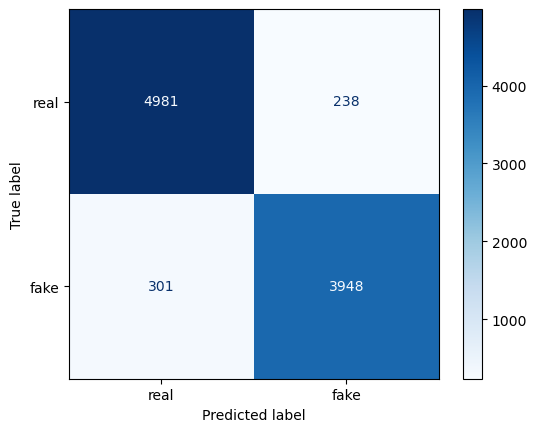

In [70]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_val, y_val_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["real", "fake"])
disp.plot(cmap="Blues")
plt.show()

In [73]:
# Reset index so it lines up cleanly with y_val_pred (which is a plain numpy array, 0-indexed)
X_val_reset = X_val.reset_index(drop=True)
y_val_reset = y_val.reset_index(drop=True)

# Boolean masks for the two error types
false_negatives_mask = (y_val_reset == 1) & (y_val_pred == 0)  # actually fake, predicted real
false_positives_mask = (y_val_reset == 0) & (y_val_pred == 1)  # actually real, predicted fake


false_negatives = X_val_reset[false_negatives_mask]
false_positives = X_val_reset[false_positives_mask]

print("=== FALSE NEGATIVES (fake predicted as real) ===")
print(false_negatives[["title", "text"]].head(3))

print("\n=== FALSE POSITIVES (real predicted as fake) ===")
print(false_positives[["title", "text"]].head(3))

=== FALSE NEGATIVES (fake predicted as real) ===
                                                 title  \
291  ivanka trump legally barred from participating...   
316  this is clinton’s supreme court plan, and it c...   
343  ann garrison: clinton serves the interests of ...   

                                                  text  
291  the office of government ethics has said that ...  
316  hillary clinton is about to step up the fight ...  
343  68 shares 67 0 0 1 mohsen abdelmoumen : do you...  

=== FALSE POSITIVES (real predicted as fake) ===
                                                title  \
3   immigration puzzle confounds republican 2016 f...   
37  fbi’s brazen terrorism lie: what the boston ma...   
72  why did mexico invite donald trump for a visit...   

                                                 text  
3   republicans are girding for a 2016 campaign de...  
37  close to the end of the march 25 testimony in ...  
72  president enrique peña nieto has invite